In [70]:
%reload_ext autoreload
%autoreload 2

In [71]:
from waymo_agent import *

In [72]:
from waymo_agent.osmnx.inspect import *
from waymo_agent.osmnx.osmnx_constants import *
from waymo_agent.osmnx.sparsify import *
from waymo_agent.osmnx.utils import _max_speed_int

In [73]:
G_raw = ox.graph_from_place(
    "Manhattan, New York, USA",
    network_type="drive",
    simplify=True,
)


print(f"Nodes: {G_raw.number_of_nodes()}")
print(f"Edges: {G_raw.number_of_edges()}")

Nodes: 4619
Edges: 9901


## Basic Save / Load

In [74]:
MAP_DIR

PosixPath('/Users/Akseldkw/coding/Columbia/RL-Project/maps')

In [75]:
ox.save_graphml(G_raw, filepath=MAP_DIR / MANHATTAN_RAW_GRAPH)

In [76]:
G_out = ox.load_graphml(filepath=MAP_DIR / MANHATTAN_RAW_GRAPH)

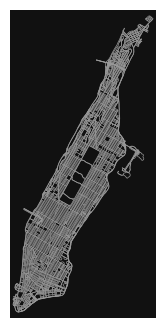

In [77]:
fig, ax = ox.plot_graph(G_out, node_size=0, edge_linewidth=0.5, figsize=(4, 4))

## Preprocess Graph

In [78]:
G = preprocess_graph(G_raw)

In [79]:
collect_unique_graph_attr(G, "maxspeed")

{2, 5, 10, 14, 15, 18, 20, 22, 25, 28, 30, 32, 35, 40, 44, 45, 48, 50}

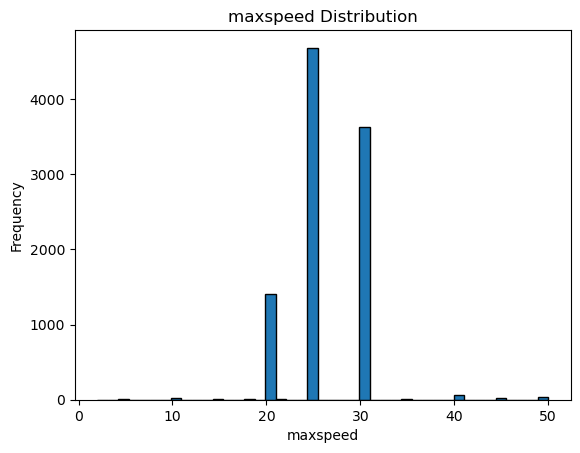

In [80]:
plot_maxspeed(G)

In [81]:
collect_unique_graph_attr(G, "maxspeed")

{2, 5, 10, 14, 15, 18, 20, 22, 25, 28, 30, 32, 35, 40, 44, 45, 48, 50}

In [82]:
ox.save_graphml(G, filepath=MAP_DIR / MANHATTAN_PROCESSED_GRAPH)

## Sparsify Graph

In [83]:
G = sparsify_graph(G)

Removing 4727 non-major edges...
Graph after edge removal: G_sparsified.number_of_nodes()=3517, G_sparsified.number_of_edges()=5173
Cleaning all edge attributes before simplification...
Cleaning all edge attributes before simplification...
Removing 110 isolated or pass-through nodes...
Cleaning all edge attributes before simplification...
Final simplified graph: G_ret.number_of_nodes()=774, G_ret.number_of_edges()=1613


In [84]:
sparse_graph_name = MANHATTAN_SPARSE_GRAPH.format(G.number_of_nodes())
sparse_graph_name

'manhattan-sparse-774-nodes.graphml'

In [85]:
ox.save_graphml(G, filepath=MAP_DIR / sparse_graph_name)

#### Load Sparse Graph

In [86]:
G = ox.load_graphml(filepath=MAP_DIR / sparse_graph_name)

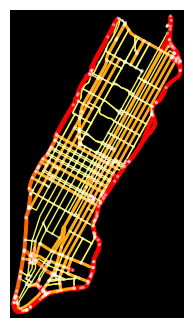

In [87]:
edge_colors, edge_widths = OSMNXConstants.get_edge_colors(G)
fig, ax = ox.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,
    **{**DEFAULT_OX_PLOT_NOTEBOOK | {"figsize": (4, 4)}},
)

## Enrich Graph 

Add lambda (demand) and charger info

In [88]:
G = ox.load_graphml(filepath=MAP_DIR / sparse_graph_name)
post_load(G)

In [89]:
enrich_graph(G)

Assigned lambda values to nodes. Total lambda: 8.8405 (target: 7.7400)


In [90]:
inspect_graph(G)

Graph has 774 nodes and 1613 edges.
Sample node -sample_node_id=5804835269- attributes: {'y': 40.7161863, 'x': -73.9874808, 'highway': 'crossing', 'street_count': 3, 'lambda': 0.0, 'x_centered': -616.5237168562599, 'y_centered': -4291.825237580575, 'x_norm': -0.08609055199710768, 'y_norm': -0.5993047691052146}

Sample edge attributes: {'osmid': 46482602, 'highway': 'secondary', 'lanes': '2', 'name': 'West 46th Street', 'oneway': True, 'reversed': False, 'length': 273.8038502364205, 'geometry': <LINESTRING (-73.994 40.762, -73.993 40.762, -73.991 40.761, -73.991 40.761)>, 'maxspeed': 48.2802, 'unit': 'kph', 'travel_time_min': 0.3402684954533169}


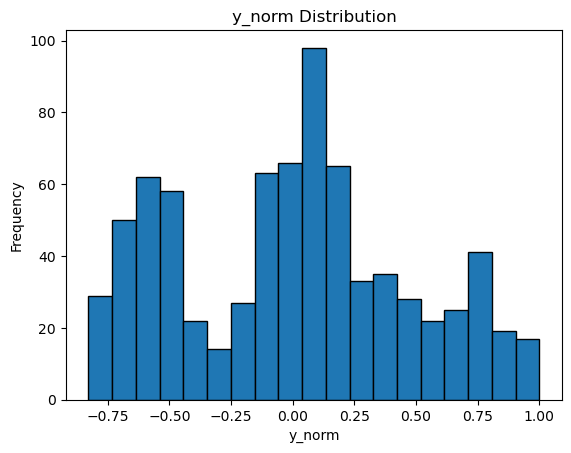

In [91]:
plot_edge_or_node_attr(G, "y_norm", "node")

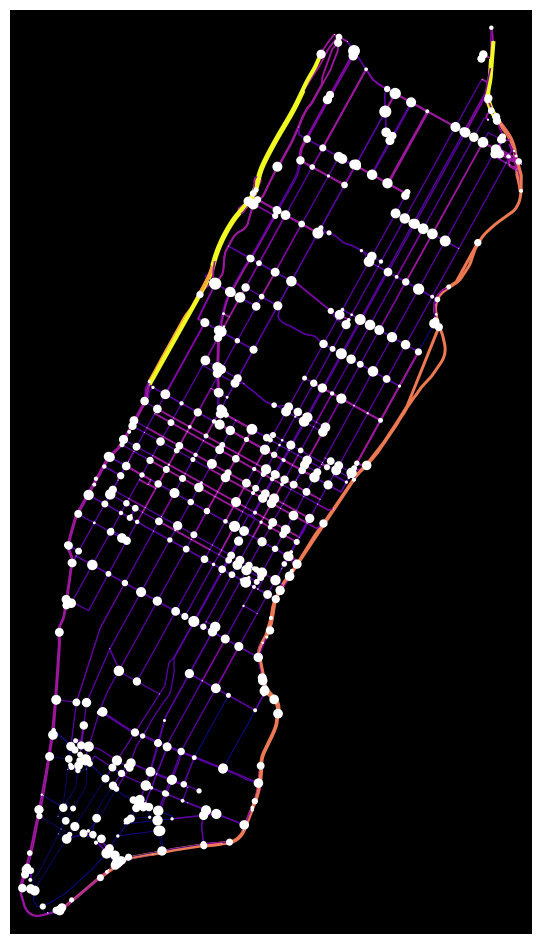

In [92]:
edge_colors, edge_widths = get_edge_color_by_speed(G)
node_colors, node_sizes = get_node_colors_and_sizes(G)
fig, ax = ox.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,
    node_size=node_sizes,
    node_color=node_colors,
    figsize=(12, 12),
    show=False,
    bgcolor="black",
)

In [93]:
name = MANHATTAN_ENRICHED_GRAPH.format(G.number_of_nodes())
ox.save_graphml(G, filepath=MAP_DIR / name)

In [94]:
name

'manhattan-sparse-774-nodes-enriched.graphml'